# Template ArcPy - Treffeisen

## 1. Import relevant modules

In [4]:
import arcpy
arcpy.CheckOutExtension('Spatial')
arcpy.CheckOutExtension('Image')
from arcpy.sa import *
from arcpy.ia import *

import json

## 2. Set environment workspace

In [5]:
arcpy.env.workspace = r'F:\newData\testworkspace.gdb'

## 3. Import a raster dataset

* *different file-types are possible*
* *if file is not in the environment workspace -> whole filepath is needed*

In [6]:
test_r = Raster(r'copyraster1914')   # Insert raster filepath here

## 4. Visualize raster data

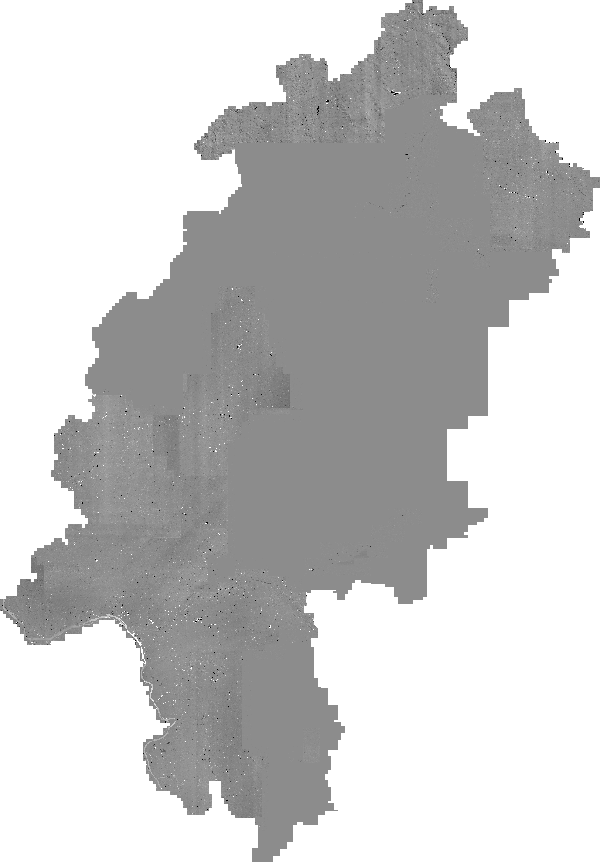

In [7]:
test_r

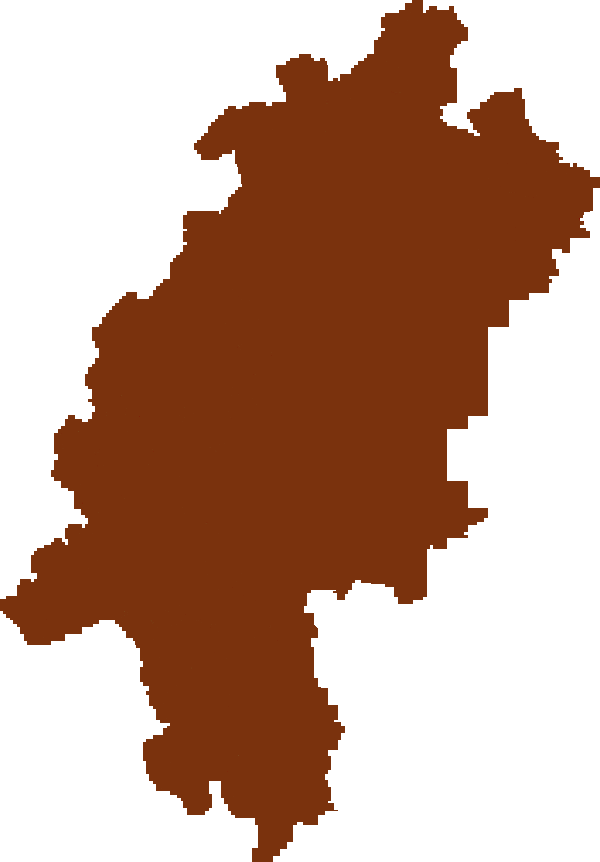

In [8]:
Render(test_r, colormap='Elevation #1')

## 5. Raster - Statistics, Object Properties and Methods

* *mean value of the raster*
* *size of the raster*
* *number of bands of the raster*
* *Dimensions of the raster*

In [9]:
test_r.mean

0.0011943378384374512

In [10]:
print('The size of the raster is {} x {}'.format(test_r.height, test_r.width))

The size of the raster is 253001 x 176001


In [11]:
print('The raster has {} band(s)'.format(test_r.bandCount))

The raster has 1 band(s)


In [ ]:
#test_r.getDimensions('...') # input a file for example

* *get information about the raster in JSON-Format*

In [12]:
test_r_info = test_r.getRasterInfo()
print(json.dumps(json.loads(test_r_info.toJSONString()), indent=2))
# print(json.dumps(json.loads(test_r.mdinfo), indent=2)) # for multidimension raster?

{
  "extent": {
    "xmin": 410999.5,
    "ymin": 5470999.5,
    "xmax": 587000.5,
    "ymax": 5724000.5,
    "spatialReference": {
      "wkid": 25832,
      "latestWkid": 25832
    }
  },
  "geodataXform": {
    "spatialReference": {
      "wkid": 25832,
      "latestWkid": 25832
    },
    "type": "IdentityXform"
  },
  "blockWidth": 128,
  "blockHeight": 128,
  "bandCount": 1,
  "pixelType": "F32",
  "pixelSizeX": 1,
  "pixelSizeY": 1,
  "format": "FGDBR",
  "compressionType": "",
  "firstPyramidLevel": 1,
  "maximumPyramidLevel": 9,
  "packetSize": 4,
  "compressionQuality": 0,
  "pyramidResamplingType": 0,
  "statistics": [
    {
      "min": -523.27099609375,
      "max": 244.14901733398438,
      "mean": 0.0011943378384374512,
      "standardDeviation": 0.3110438819972212,
      "skipX": 1,
      "skipY": 1,
      "count": 0
    }
  ],
  "histograms": [
    {
      "size": 256,
      "min": -523.27099609375,
      "max": 244.14901733398438,
      "counts": [
        1,
        

## 5. Data preprocessing

* *Clip raster to a certain AOI*
* *Resample cellsize of the raster*
* *Print new cellsize to confirm changes*
* *Save temporary raster*

In [22]:
test_r_clip = Clip(test_r, r'aoi') #insert filepath or name of AOI file

In [15]:
#test_r_final = Resample(test_r_clip, "Bilinear", 30, 100) # Resampling Techniques: Nearest | Majority | Bilinear | Cubic (!Docu has other syntax..!)

In [23]:
print('New cell size is {} x {}'.format(test_r_final.meanCellWidth,test_r_final.meanCellHeight))

New cell size is 100.0 x 100.0


In [24]:
test_r_clip.save() # name if stored in workspace or complete filepath + name r'test_1914_clip', 'tif'

## 6. List Rasters in Workspace

* *list all rasters*
* *list raster with name starting ...*
* *list all xy-format raster*
* *print list of all rasters*
* *loop through all rasters and do preprocessing*

In [ ]:
test_rasters = arcpy.listRasters()

In [ ]:
test_rasters = arcpy.listRasters('..*')

In [ ]:
test_rasters = arcpy.listRasters('*', 'FORMAT')

In [ ]:
test_rasters

In [ ]:
for raster in rasters:
    raster_clip = Clip(raster, r'AOI') # Filename or filepath of AOI
    raster_final = Resample(raster_clip, "Bilinear", 30, 100)
    raster_final.save(raster +'_p')